In [ ]:
import sys
import os
import re
import json
import random
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from IPython.display import HTML, display
import html

import torch
from transformers import pipeline
from tqdm.auto import tqdm
from datasets import load_dataset
from captum.attr import LayerIntegratedGradients

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the 'src' directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import (
    add_classifier_outputs,
    attach_split,
    highlight_spans,
    make_json_serializable,
    mask_spans_in_text,
    normalize_text,
    predict_with_pipeline,
    trim_char_span,
)

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/transformers/data/metrics/__init__.py:19: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import pearsonr, spearmanr


In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dataset and model
DATASET_NAME = "timonziegenbein/appropriateness-corpus"
MODEL_NAME = "timonziegenbein/appropriateness-classifier-binary"

# Columns
TEXT_COL = "post_text"
TEXT_NORM_COL = "text_norm"
LABEL_COL = "Inappropriateness"
ID_COL = "post_id"

# Class labels used by the Hugging Face classifier
APPROPRIATE_LABEL = "LABEL_0"
INAPPROPRIATE_LABEL = "LABEL_1"

# Inference settings
MAX_LENGTH = 512
BATCH_SIZE = 16
DEVICE = 0 if torch.cuda.is_available() else -1
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Integrated Gradients settings
N_STEPS = 32
INTERNAL_BATCH_SIZE = 8

# Config search settings
QUANTILE_VALUES = [0.3, 0.4, 0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]
WINDOW_SIZE_VALUES = [0, 1, 2, 3]

ABLATION_MODE = "mask"

# Output
BASE_DIR = Path("results")
OUTPUT_DIR = BASE_DIR / "ig_results"
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Pipeline device:", DEVICE)
print("Torch device:", TORCH_DEVICE)

Pipeline device: 0
Torch device: cuda


In [3]:
pipe = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=DEVICE,
    top_k=None,
    truncation=True,
    max_length=MAX_LENGTH
)

tokenizer = pipe.tokenizer
model = pipe.model
model.to(TORCH_DEVICE)
model.eval()

MASK_TOKEN = tokenizer.mask_token if tokenizer.mask_token is not None else "[MASK]"

# Resolve class index for LABEL_1.
if hasattr(model.config, "label2id") and INAPPROPRIATE_LABEL in model.config.label2id:
    TARGET_CLASS_IDX = int(model.config.label2id[INAPPROPRIATE_LABEL])
else:
    id2label = {int(k): v for k, v in model.config.id2label.items()}
    TARGET_CLASS_IDX = [k for k, v in id2label.items() if v == INAPPROPRIATE_LABEL][0]

# Baseline token for Integrated Gradients.
# PAD is used as the default reference input. If unavailable, fall back to MASK or UNK.
if tokenizer.pad_token_id is not None:
    BASELINE_TOKEN_ID = tokenizer.pad_token_id
elif tokenizer.mask_token_id is not None:
    BASELINE_TOKEN_ID = tokenizer.mask_token_id
else:
    BASELINE_TOKEN_ID = tokenizer.unk_token_id

# Embedding layer used by Captum's LayerIntegratedGradients.
base_model = getattr(model, model.base_model_prefix)
embedding_layer = base_model.embeddings

print("Mask token:", MASK_TOKEN)
print("Baseline token id:", BASELINE_TOKEN_ID)
print("Model labels:", model.config.id2label)
print("Target class index:", TARGET_CLASS_IDX)
print("Embedding layer:", embedding_layer.__class__.__name__)

Mask token: [MASK]
Baseline token id: 0
Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}
Target class index: 1
Embedding layer: DebertaV2Embeddings


In [ ]:
ds = load_dataset(DATASET_NAME)

train_df_raw = ds["train"].to_pandas()
val_df_raw = ds["validation"].to_pandas()
test_df_raw = ds["test"].to_pandas()

df_all = pd.concat(
    [
        attach_split(train_df_raw, "train"),
        attach_split(val_df_raw, "validation"),
        attach_split(test_df_raw, "test"),
    ],
    ignore_index=True
)

# Stable ID for comparing results across methods.
df_all["global_row_id"] = np.arange(len(df_all))

train_df = df_all[df_all["split"] == "train"].copy().reset_index(drop=True)
val_df = df_all[df_all["split"] == "validation"].copy().reset_index(drop=True)
test_df = df_all[df_all["split"] == "test"].copy().reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

df_all[["global_row_id", "split", ID_COL, LABEL_COL, TEXT_COL]].head()

Train: (1533, 21)
Validation: (220, 21)
Test: (438, 21)


,global_row_id,split,post_id,Inappropriateness,post_text
0,0,train,1,1,"people cant be forced to wear school uniforms,..."
1,1,train,2,1,"That form of argument degrades this forum, and..."
2,2,train,3,0,I wouldnt turn her in becuase she is my wife. ...
3,3,train,4,1,No I wouldn't turn in my spouse. Just because ...
4,4,train,5,1,TV is terrible. Except for Spongebob maybe. Th...


In [ ]:
for df in [train_df, val_df, test_df]:
    df[TEXT_NORM_COL] = df[TEXT_COL].apply(normalize_text)

train_df[[TEXT_COL, TEXT_NORM_COL]].head()

,post_text,text_norm
0,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,..."
1,"That form of argument degrades this forum, and...","That form of argument degrades this forum, and..."
2,I wouldnt turn her in becuase she is my wife. ...,I wouldnt turn her in becuase she is my wife. ...
3,No I wouldn't turn in my spouse. Just because ...,No I wouldn't turn in my spouse. Just because ...
4,TV is terrible. Except for Spongebob maybe. Th...,TV is terrible. Except for Spongebob maybe. Th...


In [ ]:
train_df = add_classifier_outputs(
    train_df,
    classifier=pipe,
    text_col=TEXT_NORM_COL,
    label_col=LABEL_COL,
    inappropriate_label=INAPPROPRIATE_LABEL,
    batch_size=BATCH_SIZE,
)

val_df = add_classifier_outputs(
    val_df,
    classifier=pipe,
    text_col=TEXT_NORM_COL,
    label_col=LABEL_COL,
    inappropriate_label=INAPPROPRIATE_LABEL,
    batch_size=BATCH_SIZE,
)

test_df = add_classifier_outputs(
    test_df,
    classifier=pipe,
    text_col=TEXT_NORM_COL,
    label_col=LABEL_COL,
    inappropriate_label=INAPPROPRIATE_LABEL,
    batch_size=BATCH_SIZE,
)

print("Train confusion types:")
display(train_df["confusion_type"].value_counts())

print("Validation confusion types:")
display(val_df["confusion_type"].value_counts())

print("Test confusion types:")
display(test_df["confusion_type"].value_counts())

Classifier inference:   0%|          | 0/96 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Classifier inference:   0%|          | 0/14 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/28 [00:00<?, ?it/s]

Train confusion types:


confusion_type
TP    785
TN    652
FN     48
FP     48
Name: count, dtype: int64

Validation confusion types:


confusion_type
TP    88
TN    66
FN    36
FP    30
Name: count, dtype: int64

Test confusion types:


confusion_type
TP    186
TN    142
FP     71
FN     39
Name: count, dtype: int64

# Integrated-Gradients-based span localization

This notebook evaluates Integrated Gradients as a gradient-based span localization method for the document-level inappropriateness classifier.

The method uses only `post_text` as input. It computes token-level attributions for the `inappropriate` class and then aggregates subword attributions to word-level scores. Candidate spans are created by selecting high-attribution words and merging nearby selected words into readable text spans.

The resulting spans are validated through perturbation masking. If masking the selected span decreases the model's predicted probability of `LABEL_1`, the span is treated as more faithful to the document-level prediction.

The tuned hyperparameters are:

- `quantile`
- `window_size`

## Quantile and window size

Integrated Gradients produces signed attribution scores. In this notebook, only positive word-level attributions are used for span extraction because the target is to identify words that contribute positively to the `inappropriate` class.

### Quantile

The `quantile` controls how selective the method is when choosing words based on positive IG scores.

For example:

- `quantile = 0.80` selects words in the top 20% of the positive attribution-score distribution.
- `quantile = 0.90` selects words in the top 10%.
- `quantile = 0.95` selects only the strongest positive words.

Higher quantiles usually produce shorter and more focused spans. Lower quantiles produce longer and more inclusive spans.

### Window size

In this notebook, `window_size` is used as a merge-gap parameter. It does **not** add a fixed number of words to the left and right of each selected word. Instead, it determines how many unselected words may lie between selected words for them to be merged into one span.

For example:

```text
selected_word   unselected_word   selected_word

In [8]:
def forward_func(input_ids, attention_mask):
    """
    Forward function used by Captum.
    
    It returns the logit of the inappropriate class.
    Logits are used instead of probabilities to reduce saturation effects.
    """
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )
    return outputs.logits[:, TARGET_CLASS_IDX]


lig = LayerIntegratedGradients(forward_func, embedding_layer)


def make_reference_input_ids(input_ids):
    """
    Build reference input IDs for Integrated Gradients.
    
    Special tokens are kept unchanged. All real text tokens are replaced by
    the baseline token.
    """
    ref_input_ids = input_ids.clone()
    special_ids = set(tokenizer.all_special_ids)
    
    token_list = input_ids[0].detach().cpu().tolist()
    
    for i, token_id in enumerate(token_list):
        if token_id not in special_ids:
            ref_input_ids[0, i] = BASELINE_TOKEN_ID
    
    return ref_input_ids

In [9]:
def compute_ig_data(text, max_length=MAX_LENGTH, n_steps=N_STEPS):
    """
    Compute Integrated Gradients for one text and aggregate subword attributions to words.
    
    Returns:
    - model tokens and character offsets
    - token-level signed IG scores
    - word-level signed and positive IG scores
    - metadata for span construction
    """
    encoded = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True,
        return_special_tokens_mask=True,
        return_tensors="pt"
    )
    
    word_ids = encoded.word_ids(batch_index=0) if tokenizer.is_fast else None
    offset_mapping = encoded.pop("offset_mapping")[0].tolist()
    special_tokens_mask = encoded.pop("special_tokens_mask")[0].tolist()
    
    input_ids_cpu = encoded["input_ids"]
    input_ids = encoded["input_ids"].to(TORCH_DEVICE)
    attention_mask = encoded["attention_mask"].to(TORCH_DEVICE)
    
    input_id_list = input_ids_cpu[0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(input_id_list)
    
    valid_token_mask = []
    
    for i, (start, end) in enumerate(offset_mapping):
        is_real_text_token = (
            special_tokens_mask[i] == 0
            and end > start
            and start >= 0
            and end <= len(text)
        )
        valid_token_mask.append(is_real_text_token)
    
    valid_token_mask = np.array(valid_token_mask, dtype=bool)
    
    ref_input_ids = make_reference_input_ids(input_ids).to(TORCH_DEVICE)
    
    model.zero_grad(set_to_none=True)
    
    attributions, convergence_delta = lig.attribute(
        inputs=input_ids,
        baselines=ref_input_ids,
        additional_forward_args=(attention_mask,),
        n_steps=n_steps,
        internal_batch_size=INTERNAL_BATCH_SIZE,
        return_convergence_delta=True
    )
    
    # Shape: [1, seq_len, hidden_dim] -> [seq_len]
    token_scores = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
    token_scores = np.array(token_scores, dtype=float)
    
    # Ignore special tokens.
    token_scores[~valid_token_mask] = 0.0
    
    # Normalize by total absolute attribution mass over real text tokens.
    denom = np.sum(np.abs(token_scores[valid_token_mask])) + 1e-12
    token_scores = token_scores / denom
    
    grouped_words = {}
    
    for token_idx, (token_id, offset, score) in enumerate(
        zip(input_id_list, offset_mapping, token_scores)
    ):
        if not valid_token_mask[token_idx]:
            continue
        
        char_start, char_end = int(offset[0]), int(offset[1])
        
        if word_ids is not None:
            word_id = word_ids[token_idx]
            if word_id is None:
                continue
        else:
            word_id = token_idx
        
        if word_id not in grouped_words:
            grouped_words[word_id] = {
                "token_indices": [],
                "token_texts": [],
                "char_start": char_start,
                "char_end": char_end,
                "score": 0.0
            }
        
        grouped_words[word_id]["token_indices"].append(int(token_idx))
        grouped_words[word_id]["token_texts"].append(tokens[token_idx])
        grouped_words[word_id]["char_start"] = min(
            grouped_words[word_id]["char_start"],
            char_start
        )
        grouped_words[word_id]["char_end"] = max(
            grouped_words[word_id]["char_end"],
            char_end
        )
        grouped_words[word_id]["score"] += float(score)
    
    words = []
    
    for word_id in sorted(grouped_words.keys()):
        item = grouped_words[word_id]
        char_start = int(item["char_start"])
        char_end = int(item["char_end"])
        signed_score = float(item["score"])
        
        words.append({
            "word_index": int(len(words)),
            "char_start": char_start,
            "char_end": char_end,
            "text": text[char_start:char_end],
            "score": signed_score,
            "positive_score": float(max(signed_score, 0.0)),
            "abs_score": float(abs(signed_score)),
            "token_indices": item["token_indices"],
            "token_start_idx": int(min(item["token_indices"])),
            "token_end_idx": int(max(item["token_indices"])),
            "token_texts": item["token_texts"],
            "n_tokens": int(len(item["token_indices"]))
        })
    
    return {
        "text": text,
        "tokens": tokens,
        "offset_mapping": offset_mapping,
        "valid_token_mask": valid_token_mask,
        "token_ig_scores": token_scores,
        "words": words,
        "n_model_tokens": int(valid_token_mask.sum()),
        "n_words": int(len(words)),
        "ig_convergence_delta": float(convergence_delta.detach().cpu().mean().item()),
        "was_truncated": bool(input_ids.shape[1] >= max_length)
    }

In [ ]:
# Example
example_text = val_df.iloc[0][TEXT_NORM_COL]
example_pred = predict_with_pipeline(
    [example_text],
    classifier=pipe,
    inappropriate_label=INAPPROPRIATE_LABEL,
    batch_size=BATCH_SIZE,
)
example_ig = compute_ig_data(example_text)

display(example_pred)

pd.DataFrame(example_ig["words"])[
    [
        "word_index",
        "text",
        "score",
        "positive_score",
        "char_start",
        "char_end",
        "token_start_idx",
        "token_end_idx",
        "token_texts"
    ]
].head(20)

Classifier inference:   0%|          | 0/1 [00:00<?, ?it/s]

,p_inappropriate_original,predicted_label,predicted_score
0,0.998432,LABEL_1,0.998432


,word_index,text,score,positive_score,char_start,char_end,token_start_idx,token_end_idx,token_texts
0,0,The,0.038096,0.038096,0,3,1,1,[▁The]
1,1,only,0.025511,0.025511,3,8,2,2,[▁only]
2,2,other,0.018365,0.018365,8,14,3,3,[▁other]
3,3,choices,0.019681,0.019681,14,22,4,4,[▁choices]
4,4,"are,",0.002832,0.002832,22,27,5,6,"[▁are, ,]"
5,5,adoption,-0.030254,0.000000,27,36,7,7,[▁adoption]
6,6,or,-0.006956,0.000000,36,39,8,8,[▁or]
7,7,keep,0.000518,0.000518,39,44,9,9,[▁keep]
8,8,it.,-0.006208,0.000000,44,48,10,11,"[▁it, .]"
9,9,And,0.012415,0.012415,48,52,12,12,[▁And]


In [ ]:
def selected_word_indices(ig_data, quantile):
    """
    Select words whose positive IG score is above the given per-argument quantile.
    
    Only positive attributions are considered because the target is to identify
    evidence that increases the inappropriate logit.
    """
    words = ig_data["words"]
    
    if not words:
        return []
    
    positive_scores = np.array(
        [word["positive_score"] for word in words],
        dtype=float
    )
    
    positive_only = positive_scores[positive_scores > 0]
    
    if len(positive_only) == 0:
        return []
    
    threshold = np.quantile(positive_only, quantile)
    
    selected = [
        i for i, score in enumerate(positive_scores)
        if score >= threshold and score > 0
    ]
    
    return selected


def build_spans_from_selected_words(ig_data, selected_indices, window_size):
    """
    Build merged spans from selected IG words.
    
    In this IG setup, window_size is a merge-gap parameter:
    - window_size=0 merges only directly adjacent selected words.
    - window_size=1 also merges selected words with one unselected word in between.
    - window_size=2 allows up to two unselected words in between.
    
    This is not a symmetric left/right expansion.
    """
    text = ig_data["text"]
    words = ig_data["words"]
    
    if not selected_indices:
        return []
    
    selected_indices = sorted(selected_indices)
    
    groups = []
    current = [selected_indices[0]]
    
    for idx in selected_indices[1:]:
        previous = current[-1]
        
        if idx - previous <= window_size + 1:
            current.append(idx)
        else:
            groups.append(current)
            current = [idx]
    
    groups.append(current)
    
    spans = []
    
    for group in groups:
        word_start_idx = min(group)
        word_end_idx = max(group)
        
        span_words = words[word_start_idx:word_end_idx + 1]
        selected_words = [words[idx] for idx in group]
        
        char_start = min(word["char_start"] for word in span_words)
        char_end = max(word["char_end"] for word in span_words)
        char_start, char_end = trim_char_span(text, char_start, char_end)
        
        if char_end <= char_start:
            continue
        
        token_indices_in_span = sorted({
            token_idx
            for word in span_words
            for token_idx in word["token_indices"]
        })
        
        selected_token_indices = sorted({
            token_idx
            for word in selected_words
            for token_idx in word["token_indices"]
        })
        
        selected_scores = np.array(
            [word["positive_score"] for word in selected_words],
            dtype=float
        )
        
        spans.append({
            "char_start": int(char_start),
            "char_end": int(char_end),
            "word_start_idx": int(word_start_idx),
            "word_end_idx": int(word_end_idx),
            "token_start_idx": int(min(token_indices_in_span)),
            "token_end_idx": int(max(token_indices_in_span)),
            "span_text": text[char_start:char_end],
            "span_len_chars": int(char_end - char_start),
            "span_len_words": int(word_end_idx - word_start_idx + 1),
            "span_len_tokens": int(len(token_indices_in_span)),
            "selected_word_indices": [int(idx) for idx in group],
            "selected_word_texts": [word["text"] for word in selected_words],
            "selected_token_indices": selected_token_indices,
            "selected_token_texts": [
                ig_data["tokens"][idx]
                for idx in selected_token_indices
            ],
            "span_score_sum_ig": float(selected_scores.sum()),
            "span_score_mean_ig": float(selected_scores.mean()),
            "span_score_max_ig": float(selected_scores.max())
        })
    
    for span_idx, span in enumerate(spans):
        span["span_idx"] = int(span_idx)
    
    return spans

In [11]:
def run_ig_config_on_indices(
    df,
    matrix_positions,
    quantile_values,
    window_size_values,
    mask_token=MASK_TOKEN
):
    """
    Run IG span extraction and perturbation scoring.
    
    matrix_positions are split-local positions into df.
    global_row_id is stored as the stable identifier for downstream comparison.
    """
    all_results = []
    masked_texts_to_score = []
    masked_lookup = []
    
    for matrix_pos in tqdm(matrix_positions, desc="Building IG spans"):
        row = df.iloc[matrix_pos]
        
        text = str(row[TEXT_NORM_COL])
        label = int(row[LABEL_COL])
        
        try:
            ig_data = compute_ig_data(
                text=text,
                max_length=MAX_LENGTH,
                n_steps=N_STEPS
            )
            
            n_model_tokens = int(ig_data["n_model_tokens"])
            n_words = int(ig_data["n_words"])
            
            for quantile in quantile_values:
                selected_word_idxs = selected_word_indices(
                    ig_data=ig_data,
                    quantile=quantile
                )
                
                selected_token_idxs = sorted({
                    token_idx
                    for word_idx in selected_word_idxs
                    for token_idx in ig_data["words"][word_idx]["token_indices"]
                })
                
                for window_size in window_size_values:
                    merged_spans = build_spans_from_selected_words(
                        ig_data=ig_data,
                        selected_indices=selected_word_idxs,
                        window_size=window_size
                    )
                    
                    masked_text = mask_spans_in_text(
                        text=text,
                        spans=merged_spans,
                        mask_token=mask_token
                    )
                    
                    total_masked_tokens = sum(
                        span["span_len_tokens"]
                        for span in merged_spans
                    )
                    total_masked_chars = sum(
                        span["span_len_chars"]
                        for span in merged_spans
                    )
                    
                    masked_token_ratio = (
                        total_masked_tokens / n_model_tokens
                        if n_model_tokens > 0
                        else 0.0
                    )
                    
                    selected_token_ratio = (
                        len(selected_token_idxs) / n_model_tokens
                        if n_model_tokens > 0
                        else 0.0
                    )
                    
                    selected_word_ratio = (
                        len(selected_word_idxs) / n_words
                        if n_words > 0
                        else 0.0
                    )
                    
                    result = {
                        "global_row_id": int(row["global_row_id"]),
                        "split": row["split"],
                        "post_id": row[ID_COL] if ID_COL in df.columns else None,
                        "issue": row["issue"] if "issue" in df.columns else None,
                        
                        "label": label,
                        "predicted_label": row["predicted_label"],
                        "predicted_score": float(row["predicted_score"]),
                        "confusion_type": row["confusion_type"],
                        "is_true_positive": bool(row["is_true_positive"]),
                        "is_false_negative": bool(row["is_false_negative"]),
                        "is_false_positive": bool(row["is_false_positive"]),
                        "is_true_negative": bool(row["is_true_negative"]),
                        
                        "attribution_method": "integrated_gradients",
                        "quantile": float(quantile),
                        "window_size": int(window_size),
                        "ablation_mode": "mask",
                        
                        "text": text,
                        "masked_text": masked_text,
                        
                        "p_inappropriate_original": float(row["p_inappropriate_original"]),
                        
                        "n_model_tokens": n_model_tokens,
                        "n_words": n_words,
                        "n_selected_tokens": int(len(selected_token_idxs)),
                        "n_selected_words": int(len(selected_word_idxs)),
                        "selected_token_ratio": float(selected_token_ratio),
                        "selected_word_ratio": float(selected_word_ratio),
                        
                        "n_merged_spans": int(len(merged_spans)),
                        "total_masked_tokens": int(total_masked_tokens),
                        "total_masked_chars": int(total_masked_chars),
                        "masked_token_ratio": float(masked_token_ratio),
                        
                        "selected_word_indices": [int(idx) for idx in selected_word_idxs],
                        "selected_word_texts": [
                            ig_data["words"][idx]["text"]
                            for idx in selected_word_idxs
                        ],
                        "selected_token_indices": [int(idx) for idx in selected_token_idxs],
                        "selected_token_texts": [
                            ig_data["tokens"][idx]
                            for idx in selected_token_idxs
                        ],
                        
                        "merged_spans": merged_spans,
                        "ig_convergence_delta": float(ig_data["ig_convergence_delta"]),
                        "was_truncated": bool(ig_data["was_truncated"]),
                        "error": None
                    }
                    
                    all_results.append(result)
                    masked_lookup.append(len(all_results) - 1)
                    masked_texts_to_score.append(masked_text)
        
        except Exception as e:
            result = {
                "global_row_id": int(row["global_row_id"]),
                "split": row["split"],
                "post_id": row[ID_COL] if ID_COL in df.columns else None,
                "issue": row["issue"] if "issue" in df.columns else None,
                
                "label": label,
                "predicted_label": row["predicted_label"],
                "predicted_score": float(row["predicted_score"]),
                "confusion_type": row["confusion_type"],
                "is_true_positive": bool(row["is_true_positive"]),
                "is_false_negative": bool(row["is_false_negative"]),
                "is_false_positive": bool(row["is_false_positive"]),
                "is_true_negative": bool(row["is_true_negative"]),
                
                "attribution_method": "integrated_gradients",
                "quantile": None,
                "window_size": None,
                "ablation_mode": "mask",
                
                "text": text,
                "masked_text": text,
                
                "p_inappropriate_original": float(row["p_inappropriate_original"]),
                "p_inappropriate_masked": np.nan,
                "predicted_label_masked": None,
                "prob_drop": np.nan,
                
                "n_model_tokens": 0,
                "n_words": 0,
                "n_selected_tokens": 0,
                "n_selected_words": 0,
                "selected_token_ratio": 0.0,
                "selected_word_ratio": 0.0,
                "n_merged_spans": 0,
                "total_masked_tokens": 0,
                "total_masked_chars": 0,
                "masked_token_ratio": 0.0,
                
                "selected_word_indices": [],
                "selected_word_texts": [],
                "selected_token_indices": [],
                "selected_token_texts": [],
                "merged_spans": [],
                "ig_convergence_delta": np.nan,
                "was_truncated": False,
                "error": str(e)
            }
            all_results.append(result)
    
    if len(masked_texts_to_score) > 0:
        masked_predictions = predict_with_pipeline(
            masked_texts_to_score,
            batch_size=BATCH_SIZE
        )
        
        for result_idx, (_, pred_row) in zip(masked_lookup, masked_predictions.iterrows()):
            result = all_results[result_idx]
            p_masked = float(pred_row["p_inappropriate_original"])
            
            result["p_inappropriate_masked"] = p_masked
            result["predicted_label_masked"] = pred_row["predicted_label"]
            result["prob_drop"] = float(result["p_inappropriate_original"] - p_masked)
    
    return all_results

In [12]:
def build_argument_level_df(argument_results):
    """Flatten argument-level IG results for CSV export."""
    rows = []
    
    for result in argument_results:
        merged_span_texts = [span["span_text"] for span in result["merged_spans"]]
        merged_span_token_starts = [span["token_start_idx"] for span in result["merged_spans"]]
        merged_span_token_ends = [span["token_end_idx"] for span in result["merged_spans"]]
        merged_span_char_starts = [span["char_start"] for span in result["merged_spans"]]
        merged_span_char_ends = [span["char_end"] for span in result["merged_spans"]]
        
        rows.append({
            "global_row_id": result["global_row_id"],
            "split": result["split"],
            "post_id": result["post_id"],
            "issue": result["issue"],
            
            "label": result["label"],
            "predicted_label": result["predicted_label"],
            "predicted_score": result["predicted_score"],
            "confusion_type": result["confusion_type"],
            "is_true_positive": result["is_true_positive"],
            "is_false_negative": result["is_false_negative"],
            "is_false_positive": result["is_false_positive"],
            "is_true_negative": result["is_true_negative"],
            
            "attribution_method": result["attribution_method"],
            "quantile": result["quantile"],
            "window_size": result["window_size"],
            "ablation_mode": result["ablation_mode"],
            
            "p_inappropriate_original": result["p_inappropriate_original"],
            "p_inappropriate_masked": result["p_inappropriate_masked"],
            "predicted_label_masked": result["predicted_label_masked"],
            "prob_drop": result["prob_drop"],
            
            "n_model_tokens": result["n_model_tokens"],
            "n_words": result["n_words"],
            "n_selected_tokens": result["n_selected_tokens"],
            "n_selected_words": result["n_selected_words"],
            "selected_token_ratio": result["selected_token_ratio"],
            "selected_word_ratio": result["selected_word_ratio"],
            
            "n_merged_spans": result["n_merged_spans"],
            "total_masked_tokens": result["total_masked_tokens"],
            "total_masked_chars": result["total_masked_chars"],
            "masked_token_ratio": result["masked_token_ratio"],
            
            "selected_word_indices": result["selected_word_indices"],
            "selected_word_texts": result["selected_word_texts"],
            "selected_token_indices": result["selected_token_indices"],
            "selected_token_texts": result["selected_token_texts"],
            
            "merged_span_texts": merged_span_texts,
            "merged_span_token_start_indices": merged_span_token_starts,
            "merged_span_token_end_indices": merged_span_token_ends,
            "merged_span_char_start_indices": merged_span_char_starts,
            "merged_span_char_end_indices": merged_span_char_ends,
            
            "selected_words_json": json.dumps(result["selected_word_texts"], ensure_ascii=False),
            "selected_tokens_json": json.dumps(result["selected_token_texts"], ensure_ascii=False),
            "merged_spans_json": json.dumps(result["merged_spans"], ensure_ascii=False),
            
            "ig_convergence_delta": result["ig_convergence_delta"],
            "was_truncated": result["was_truncated"],
            
            "text": result["text"],
            "masked_text": result["masked_text"],
            "error": result["error"]
        })
    
    return pd.DataFrame(rows)


def build_span_level_df(argument_results):
    """Flatten span-level IG results for CSV export."""
    span_rows = []
    
    for result in argument_results:
        for span in result["merged_spans"]:
            span_rows.append({
                "global_row_id": result["global_row_id"],
                "split": result["split"],
                "post_id": result["post_id"],
                "issue": result["issue"],
                
                "label": result["label"],
                "predicted_label": result["predicted_label"],
                "confusion_type": result["confusion_type"],
                "is_true_positive": result["is_true_positive"],
                "is_false_negative": result["is_false_negative"],
                "is_false_positive": result["is_false_positive"],
                "is_true_negative": result["is_true_negative"],
                
                "attribution_method": result["attribution_method"],
                "quantile": result["quantile"],
                "window_size": result["window_size"],
                "ablation_mode": result["ablation_mode"],
                
                "span_idx": span["span_idx"],
                "span_text": span["span_text"],
                "char_start": span["char_start"],
                "char_end": span["char_end"],
                "word_start_idx": span["word_start_idx"],
                "word_end_idx": span["word_end_idx"],
                "token_start_idx": span["token_start_idx"],
                "token_end_idx": span["token_end_idx"],
                "span_len_chars": span["span_len_chars"],
                "span_len_words": span["span_len_words"],
                "span_len_tokens": span["span_len_tokens"],
                
                "selected_word_indices": span["selected_word_indices"],
                "selected_word_texts": span["selected_word_texts"],
                "selected_token_indices": span["selected_token_indices"],
                "selected_token_texts": span["selected_token_texts"],
                "span_score_sum_ig": span["span_score_sum_ig"],
                "span_score_mean_ig": span["span_score_mean_ig"],
                "span_score_max_ig": span["span_score_max_ig"],
                
                "p_inappropriate_original": result["p_inappropriate_original"],
                "p_inappropriate_masked": result["p_inappropriate_masked"],
                "prob_drop": result["prob_drop"],
                
                "n_model_tokens": result["n_model_tokens"],
                "n_words": result["n_words"],
                "n_selected_tokens": result["n_selected_tokens"],
                "n_selected_words": result["n_selected_words"],
                "selected_token_ratio": result["selected_token_ratio"],
                "selected_word_ratio": result["selected_word_ratio"],
                "masked_token_ratio": result["masked_token_ratio"],
                
                "ig_convergence_delta": result["ig_convergence_delta"],
                "was_truncated": result["was_truncated"],
                
                "text": result["text"],
                "masked_text": result["masked_text"]
            })
    
    return pd.DataFrame(span_rows)

# Config selection

In [13]:
dev_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

train_tp_positions = train_df.index[
    train_df["confusion_type"] == "TP"
].tolist()

val_tp_positions = val_df.index[
    val_df["confusion_type"] == "TP"
].tolist()

dev_tp_positions = dev_df.index[
    dev_df["confusion_type"] == "TP"
].tolist()

In [19]:
dev_tp_results = run_ig_config_on_indices(
    df=dev_df,
    matrix_positions=dev_tp_positions,
    quantile_values=QUANTILE_VALUES,
    window_size_values=WINDOW_SIZE_VALUES,
    mask_token=MASK_TOKEN
)

dev_tp_argument_df = build_argument_level_df(dev_tp_results)
dev_tp_span_df = build_span_level_df(dev_tp_results)

display(dev_tp_argument_df.head())
display(dev_tp_span_df.head())

Building IG spans:   0%|          | 0/873 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/1965 [00:00<?, ?it/s]

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_char_start_indices,merged_span_char_end_indices,selected_words_json,selected_tokens_json,merged_spans_json,ig_convergence_delta,was_truncated,text,masked_text,error
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[0, 47, 66, 85, 103, 119, 144, 167]","[14, 53, 75, 92, 108, 121, 151, 190]","[""people"", "" cant"", "" be"", "" i"", "" mean"", "" ha...","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁i"", ""▁mean"",...","[{""char_start"": 0, ""char_end"": 14, ""word_start...",0.31769,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ...",None
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[0, 47, 66, 85, 103, 119, 144, 167]","[14, 53, 75, 92, 108, 121, 151, 190]","[""people"", "" cant"", "" be"", "" i"", "" mean"", "" ha...","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁i"", ""▁mean"",...","[{""char_start"": 0, ""char_end"": 14, ""word_start...",0.31769,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ...",None
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[0, 47, 144]","[14, 121, 190]","[""people"", "" cant"", "" be"", "" i"", "" mean"", "" ha...","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁i"", ""▁mean"",...","[{""char_start"": 0, ""char_end"": 14, ""word_start...",0.31769,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ...",None
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[0, 47]","[14, 190]","[""people"", "" cant"", "" be"", "" i"", "" mean"", "" ha...","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁i"", ""▁mean"",...","[{""char_start"": 0, ""char_end"": 14, ""word_start...",0.31769,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ...",None
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[0, 47, 66, 85, 144, 167]","[14, 53, 75, 92, 151, 190]","[""people"", "" cant"", "" be"", "" i"", "" mean"", "" ha...","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁i"", ""▁mean"",...","[{""char_start"": 0, ""char_end"": 14, ""word_start...",0.31769,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ...",None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,n_words,n_selected_tokens,n_selected_words,selected_token_ratio,selected_word_ratio,masked_token_ratio,ig_convergence_delta,was_truncated,text,masked_text
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,38,19,17,0.452381,0.447368,0.452381,0.31769,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ..."
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,38,19,17,0.452381,0.447368,0.452381,0.31769,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ..."
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,38,19,17,0.452381,0.447368,0.452381,0.31769,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ..."
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,38,19,17,0.452381,0.447368,0.452381,0.31769,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ..."
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,38,19,17,0.452381,0.447368,0.452381,0.31769,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ..."


In [20]:
dev_tp_argument_df_valid = dev_tp_argument_df[
    dev_tp_argument_df["error"].isna()
].copy()

dev_config_summary = (
    dev_tp_argument_df_valid
    .groupby(["attribution_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_n_selected_tokens=("n_selected_tokens", "mean"),
        mean_n_selected_words=("n_selected_words", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        median_total_masked_tokens=("total_masked_tokens", "median"),
        mean_total_masked_chars=("total_masked_chars", "mean"),
        mean_selected_token_ratio=("selected_token_ratio", "mean"),
        mean_selected_word_ratio=("selected_word_ratio", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        median_masked_token_ratio=("masked_token_ratio", "median"),
        mean_ig_convergence_delta=("ig_convergence_delta", "mean"),
        truncation_rate=("was_truncated", lambda x: x.mean()),
    )
    .reset_index()
)

span_len_summary = (
    dev_tp_span_df
    .groupby(["attribution_method", "window_size", "quantile"])
    .agg(
        n_spans=("span_text", "count"),
        mean_span_len_tokens=("span_len_tokens", "mean"),
        median_span_len_tokens=("span_len_tokens", "median"),
        mean_span_len_words=("span_len_words", "mean"),
        median_span_len_words=("span_len_words", "median"),
        mean_span_len_chars=("span_len_chars", "mean"),
        median_span_len_chars=("span_len_chars", "median"),
        mean_span_score_sum_ig=("span_score_sum_ig", "mean"),
        mean_span_score_mean_ig=("span_score_mean_ig", "mean"),
    )
    .reset_index()
)

dev_config_summary = dev_config_summary.merge(
    span_len_summary,
    on=["attribution_method", "window_size", "quantile"],
    how="left"
)

dev_config_summary["prob_drop_per_masked_token"] = (
    dev_config_summary["mean_prob_drop"] /
    dev_config_summary["mean_total_masked_tokens"].replace(0, np.nan)
)

dev_config_summary["prob_drop_per_masked_ratio"] = (
    dev_config_summary["mean_prob_drop"] /
    dev_config_summary["mean_masked_token_ratio"].replace(0, np.nan)
)

dev_config_summary = dev_config_summary.sort_values(
    ["attribution_method", "window_size", "quantile"]
)

display(dev_config_summary)

,attribution_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,...,mean_span_len_tokens,median_span_len_tokens,mean_span_len_words,median_span_len_words,mean_span_len_chars,median_span_len_chars,mean_span_score_sum_ig,mean_span_score_mean_ig,prob_drop_per_masked_token,prob_drop_per_masked_ratio
0,integrated_gradients,0,0.30,873,0.071944,0.002810,0.221492,0.887743,0.295533,0.150057,...,3.183351,2.0,2.449342,2.0,12.884470,9.0,0.049371,0.020489,0.001492,0.131563
1,integrated_gradients,0,0.40,873,0.079295,0.002053,0.240564,0.885452,0.245132,0.140893,...,2.880951,2.0,2.157133,1.0,11.376422,8.0,0.048496,0.023170,0.001860,0.163954
2,integrated_gradients,0,0.50,873,0.081978,0.001480,0.247464,0.885452,0.218786,0.136312,...,2.637858,2.0,1.908610,1.0,10.104248,8.0,0.048396,0.026277,0.002208,0.194088
3,integrated_gradients,0,0.60,873,0.077649,0.001225,0.241259,0.872852,0.171821,0.130584,...,2.460149,2.0,1.703341,1.0,9.087600,7.0,0.049915,0.030751,0.002501,0.220624
4,integrated_gradients,0,0.70,873,0.073070,0.000992,0.233319,0.860252,0.170676,0.130584,...,2.309425,2.0,1.504410,1.0,8.135267,7.0,0.052489,0.036526,0.002935,0.258507
5,integrated_gradients,0,0.80,873,0.075588,0.000720,0.234965,0.844215,0.161512,0.122566,...,2.228348,2.0,1.324306,1.0,7.360737,6.0,0.058287,0.045896,0.004071,0.356470
6,integrated_gradients,0,0.85,873,0.064047,0.000616,0.216056,0.841924,0.137457,0.113402,...,2.225407,2.0,1.236092,1.0,7.040366,6.0,0.063871,0.053680,0.004261,0.372080
7,integrated_gradients,0,0.90,873,0.053977,0.000511,0.200772,0.797251,0.127148,0.100802,...,2.239738,2.0,1.137573,1.0,6.767930,6.0,0.072197,0.065142,0.004745,0.407530
8,integrated_gradients,0,0.95,873,0.045169,0.000221,0.180759,0.682703,0.095074,0.082474,...,2.243419,2.0,1.042732,1.0,6.551316,6.0,0.089813,0.087135,0.006706,0.561400
9,integrated_gradients,1,0.30,873,0.079653,0.002188,0.232098,0.867125,0.280641,0.170676,...,6.067271,4.0,4.747166,3.0,25.562736,17.0,0.082261,0.021783,0.001444,0.127371


In [21]:
dev_output_dir = OUTPUT_DIR / "dev_config_selection"
dev_output_dir.mkdir(parents=True, exist_ok=True)

dev_tp_argument_df.to_csv(
    dev_output_dir / "ig_dev_tp_argument_level.csv",
    index=False,
    encoding="utf-8"
)

dev_tp_span_df.to_csv(
    dev_output_dir / "ig_dev_tp_span_level.csv",
    index=False,
    encoding="utf-8"
)

dev_config_summary.to_csv(
    dev_output_dir / "ig_dev_config_summary.csv",
    index=False,
    encoding="utf-8"
)

print("Saved dev config selection files to:", dev_output_dir)

Saved dev config selection files to: ig_results_new/dev_config_selection


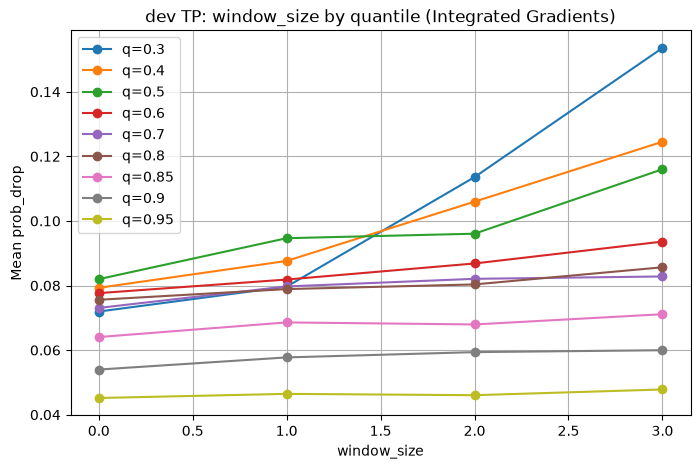

Saved plot: ig_results_new/dev_config_selection/ig_dev_window_by_quantile.png


In [22]:
method_df = dev_config_summary[
    dev_config_summary["attribution_method"] == "integrated_gradients"
].copy()

plt.figure(figsize=(8, 5))

for quantile in sorted(method_df["quantile"].unique()):
    subset = method_df[
        method_df["quantile"] == quantile
    ].sort_values("window_size")
    
    plt.plot(
        subset["window_size"],
        subset["mean_prob_drop"],
        marker="o",
        label=f"q={quantile}"
    )

plt.xlabel("window_size")
plt.ylabel("Mean prob_drop")
plt.title("dev TP: window_size by quantile (Integrated Gradients)")
plt.grid(True)
plt.legend()

plot_path = dev_output_dir / "ig_dev_window_by_quantile.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

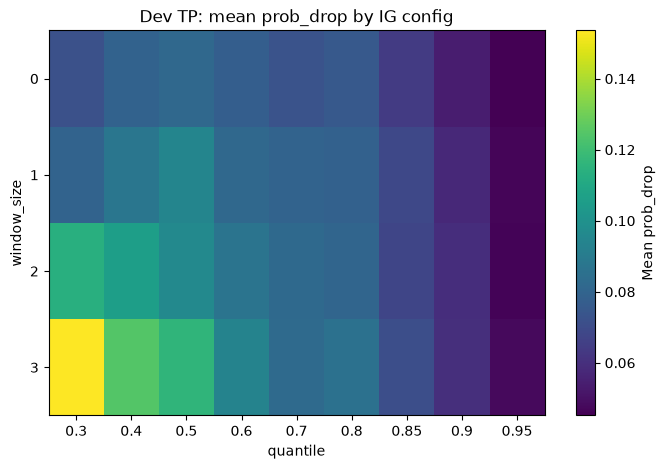

Saved plot: ig_results_new/dev_config_selection/ig_dev_find_config_heatmap.png


quantile,0.30,0.40,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,,,
0,0.071944,0.079295,0.081978,0.077649,0.073070,0.075588,0.064047,0.053977,0.045169
1,0.079653,0.087617,0.094660,0.081854,0.079717,0.078896,0.068575,0.057738,0.046453
2,0.113582,0.105981,0.096052,0.086832,0.082075,0.080343,0.067945,0.059376,0.046037
3,0.153562,0.124524,0.116003,0.093603,0.082810,0.085649,0.071111,0.059967,0.047811


In [23]:
method_df = dev_config_summary[
    dev_config_summary["attribution_method"] == "integrated_gradients"
].copy()

heatmap_data = method_df.pivot(
    index="window_size",
    columns="quantile",
    values="mean_prob_drop"
)

plt.figure(figsize=(8, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Mean prob_drop")

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)
plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.xlabel("quantile")
plt.ylabel("window_size")
plt.title("Dev TP: mean prob_drop by IG config")

plot_path = dev_output_dir / "ig_dev_find_config_heatmap.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)
display(heatmap_data)

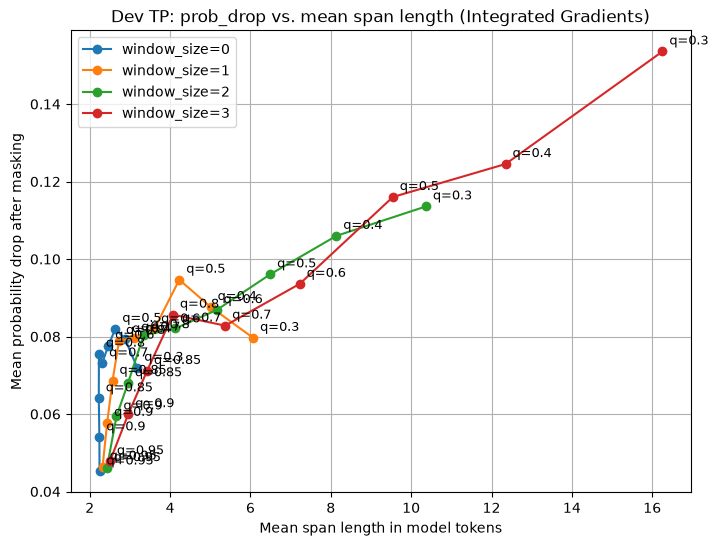

Saved plot: ig_results_new/dev_config_selection/ig_dev_prob_drop_vs_mean_span_len.png


In [24]:
method_df = dev_config_summary[
    dev_config_summary["attribution_method"] == "integrated_gradients"
].copy()

plt.figure(figsize=(8, 6))

for window_size in sorted(method_df["window_size"].unique()):
    subset = method_df[
        method_df["window_size"] == window_size
    ].sort_values("quantile")
    
    plt.plot(
        subset["mean_span_len_tokens"],
        subset["mean_prob_drop"],
        marker="o",
        label=f"window_size={window_size}"
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"q={row['quantile']}",
            (row["mean_span_len_tokens"], row["mean_prob_drop"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Mean span length in model tokens")
plt.ylabel("Mean probability drop after masking")
plt.title("Dev TP: prob_drop vs. mean span length (Integrated Gradients)")
plt.grid(True)
plt.legend()

plot_path = dev_output_dir / "ig_dev_prob_drop_vs_mean_span_len.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

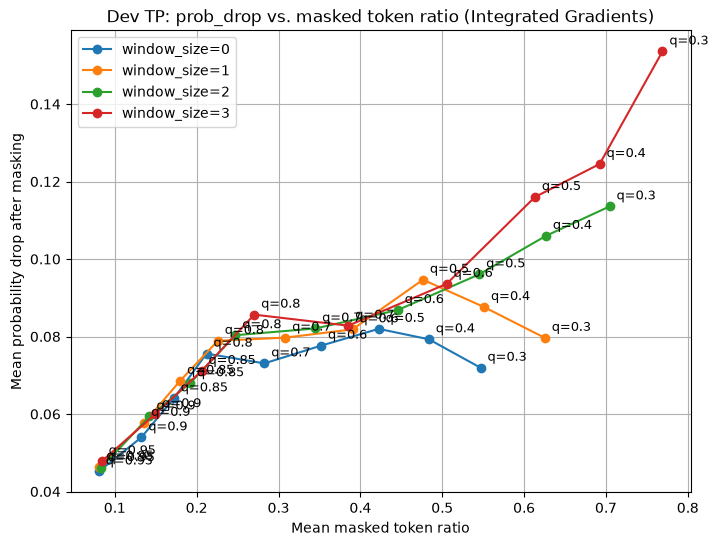

Saved plot: ig_results_new/dev_config_selection/ig_dev_prob_drop_vs_masked_token_ratio.png


In [25]:
method_df = dev_config_summary[
    dev_config_summary["attribution_method"] == "integrated_gradients"
].copy()

plt.figure(figsize=(8, 6))

for window_size in sorted(method_df["window_size"].unique()):
    subset = method_df[
        method_df["window_size"] == window_size
    ].sort_values("quantile")
    
    plt.plot(
        subset["mean_masked_token_ratio"],
        subset["mean_prob_drop"],
        marker="o",
        label=f"window_size={window_size}"
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"q={row['quantile']}",
            (row["mean_masked_token_ratio"], row["mean_prob_drop"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Mean masked token ratio")
plt.ylabel("Mean probability drop after masking")
plt.title("Dev TP: prob_drop vs. masked token ratio (Integrated Gradients)")
plt.grid(True)
plt.legend()

plot_path = dev_output_dir / "ig_dev_prob_drop_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

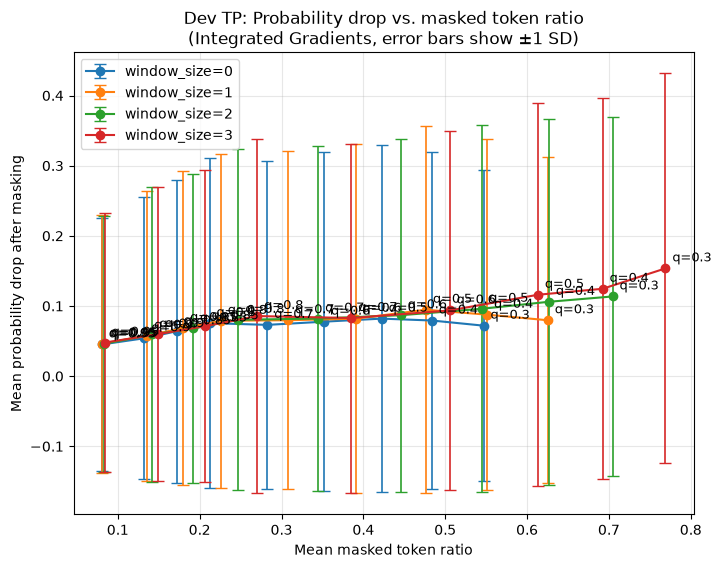

Saved plot: ig_results_new/dev_config_selection/ig_dev_prob_drop_vs_masked_token_ratio_with_std.png


In [26]:
method_df = dev_config_summary[
    dev_config_summary["attribution_method"] == "integrated_gradients"
].copy()

plt.figure(figsize=(8, 6))

for window_size in sorted(method_df["window_size"].unique()):
    subset = method_df[
        method_df["window_size"] == window_size
    ].sort_values("quantile")

    plt.errorbar(
        subset["mean_masked_token_ratio"],
        subset["mean_prob_drop"],
        yerr=subset["std_prob_drop"],
        marker="o",
        linestyle="-",
        capsize=4,
        elinewidth=1.2,
        label=f"window_size={window_size}"
    )

    for _, row in subset.iterrows():
        plt.annotate(
            f"q={row['quantile']}",
            (
                row["mean_masked_token_ratio"],
                row["mean_prob_drop"]
            ),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Mean masked token ratio")
plt.ylabel("Mean probability drop after masking")
plt.title(
    "Dev TP: Probability drop vs. masked token ratio\n"
    "(Integrated Gradients, error bars show ±1 SD)"
)
plt.grid(True, alpha=0.3)
plt.legend()

plot_path = (
    dev_output_dir
    / "ig_dev_prob_drop_vs_masked_token_ratio_with_std.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Saved plot:", plot_path)

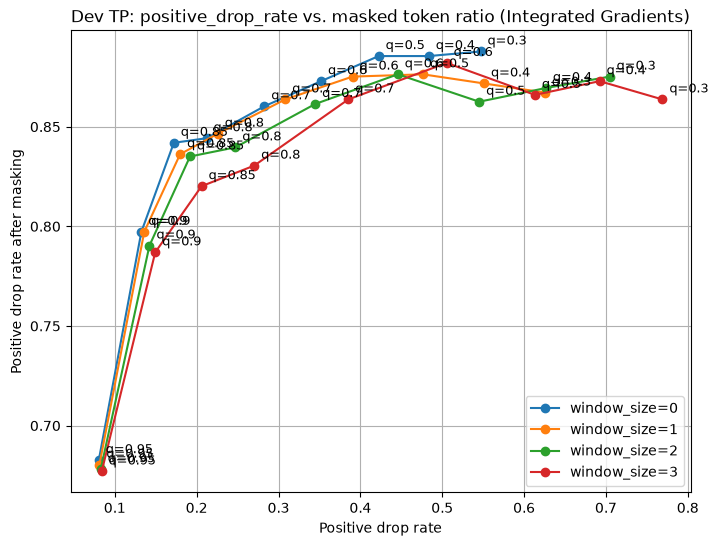

Saved plot: ig_results_new/dev_config_selection/ig_dev_positive_drop_rate_vs_masked_token_ratio.png


In [27]:
method_df = dev_config_summary[
    dev_config_summary["attribution_method"] == "integrated_gradients"
].copy()

plt.figure(figsize=(8, 6))

for window_size in sorted(method_df["window_size"].unique()):
    subset = method_df[
        method_df["window_size"] == window_size
    ].sort_values("quantile")
    
    plt.plot(
        subset["mean_masked_token_ratio"],
        subset["positive_drop_rate"],
        marker="o",
        label=f"window_size={window_size}"
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"q={row['quantile']}",
            (row["mean_masked_token_ratio"], row["positive_drop_rate"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Positive drop rate")
plt.ylabel("Positive drop rate after masking")
plt.title("Dev TP: positive_drop_rate vs. masked token ratio (Integrated Gradients)")
plt.grid(True)
plt.legend()

plot_path = dev_output_dir / "ig_dev_positive_drop_rate_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

In [28]:
# Final config selected from validation plots and summary.
dev_config_summary = pd.read_csv("ig_results_new/dev_config_selection/ig_dev_config_summary.csv")

BEST_QUANTILE = 0.5
BEST_WINDOW_SIZE = 1

selected_config_summary = dev_config_summary[
    (dev_config_summary["attribution_method"] == "integrated_gradients") &
    (dev_config_summary["quantile"] == BEST_QUANTILE) &
    (dev_config_summary["window_size"] == BEST_WINDOW_SIZE)
]

display(selected_config_summary)

,attribution_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,...,mean_span_len_tokens,median_span_len_tokens,mean_span_len_words,median_span_len_words,mean_span_len_chars,median_span_len_chars,mean_span_score_sum_ig,mean_span_score_mean_ig,prob_drop_per_masked_token,prob_drop_per_masked_ratio
11,integrated_gradients,1,0.5,873,0.09466,0.001443,0.261942,0.876289,0.219931,0.15693,...,4.229002,3.0,3.146288,2.0,16.959397,11.0,0.068989,0.027514,0.002267,0.198674


In [ ]:
def show_ig_example(result_df, index=0):
    """Display one IG result with highlighted masked spans."""
    row = result_df.iloc[index]
    
    spans = json.loads(row["merged_spans_json"])
    marked = highlight_spans(row["text"], spans)
    
    display(HTML(f"""
    <div style="
        border:1px solid #ccc;
        border-radius:8px;
        padding:14px;
        margin:12px 0;
        font-family:Arial, sans-serif;
        line-height:1.45;
    ">
        <b>global_row_id:</b> {html.escape(str(row["global_row_id"]))}<br>
        <b>post_id:</b> {html.escape(str(row["post_id"]))}<br>
        <b>split:</b> {html.escape(str(row["split"]))}<br>
        <b>confusion_type:</b> {html.escape(str(row["confusion_type"]))}<br>
        <b>issue:</b> {html.escape(str(row["issue"]))}<br>
        <b>method:</b> {html.escape(str(row["attribution_method"]))} |
        <b>quantile:</b> {row["quantile"]} |
        <b>window_size:</b> {row["window_size"]}<br>
        <b>merged_spans:</b> {html.escape(str(row["merged_span_texts"]))}<br>
        <b>p_original:</b> {float(row["p_inappropriate_original"]):.4f}<br>
        <b>p_masked:</b> {float(row["p_inappropriate_masked"]):.4f}<br>
        <b>prob_drop:</b> {float(row["prob_drop"]):.4f}<br>
        <b>masked_token_ratio:</b> {float(row["masked_token_ratio"]):.4f}<br>
        <b>IG convergence delta:</b> {float(row["ig_convergence_delta"]):.6f}<br>
        <hr>
        <p>{marked}</p>
    </div>
    """))

In [30]:
dev_best_examples = dev_tp_argument_df[
    (dev_tp_argument_df["attribution_method"] == "integrated_gradients") &
    (dev_tp_argument_df["quantile"] == BEST_QUANTILE) &
    (dev_tp_argument_df["window_size"] == BEST_WINDOW_SIZE) &
    (dev_tp_argument_df["error"].isna())
].copy()

print("Dev examples for selected IG config:", len(dev_best_examples))

display(
    dev_best_examples[
        [
            "global_row_id",
            "post_id",
            "prob_drop",
            "masked_token_ratio",
            "merged_span_texts"
        ]
    ].head()
)

Dev examples for selected IG config: 873


,global_row_id,post_id,prob_drop,masked_token_ratio,merged_span_texts
9,0,1,0.833708,0.333333,"[people cant be, i mean, theri, I think, shoul..."
45,1,2,0.001026,0.562500,"[That form of argument, and will cause, the, w..."
81,3,4,0.001549,0.593750,"[No I wouldn't turn in, the girl that, doesn't..."
117,4,5,0.000245,0.675676,"[terrible., maybe. That's an alright, the majo..."
153,5,6,0.001033,0.600000,"[I love books, I love getting, improve, (so my..."


In [31]:
tmp_top = (
    dev_best_examples
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp_top))):
    show_ig_example(tmp_top, index=i)

## Final selected Integrated Gradients configuration

The final IG configuration is selected on validation true positives only. This keeps the hyperparameter choice separate from the final test evaluation.

The final configuration is based on:

- word-level Integrated Gradients scores,
- positive attribution scores for the `inappropriate` class,
- span extraction via quantile thresholding,
- local span merging through `window_size`,
- masking-based validation on validation true positives.

A separate word-boundary post-processing step is not necessary here because subword attributions are aggregated to full words before spans are constructed.

Selected final configuration:

- `quantile = 0.85`
- `window_size = 3`

# Run best config

The selected configuration is now applied to the full train, validation, and test splits.

The configuration is not re-tuned on the test set. The test split is only used for final reporting.

In [32]:
def run_final_ig_on_split(df, split_name):
    """
    Run the selected IG configuration on one split.
    
    The final configuration is fixed and not re-tuned per split.
    """
    positions = list(range(len(df)))
    
    results = run_ig_config_on_indices(
        df=df,
        matrix_positions=positions,
        quantile_values=[BEST_QUANTILE],
        window_size_values=[BEST_WINDOW_SIZE],
        mask_token=MASK_TOKEN
    )
    
    argument_df = build_argument_level_df(results)
    span_df = build_span_level_df(results)
    
    print(f"{split_name} argument level:", argument_df.shape)
    print(f"{split_name} span level:", span_df.shape)
    
    return results, argument_df, span_df


train_results, train_argument_df, train_span_df = run_final_ig_on_split(
    train_df,
    "train"
)

val_results, val_argument_df, val_span_df = run_final_ig_on_split(
    val_df,
    "validation"
)

test_results, test_argument_df, test_span_df = run_final_ig_on_split(
    test_df,
    "test"
)

Building IG spans:   0%|          | 0/1533 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/96 [00:00<?, ?it/s]

train argument level: (1533, 47)
train span level: (14994, 47)


Building IG spans:   0%|          | 0/220 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/14 [00:00<?, ?it/s]

validation argument level: (220, 47)
validation span level: (2193, 47)


Building IG spans:   0%|          | 0/438 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/28 [00:00<?, ?it/s]

test argument level: (438, 47)
test span level: (4266, 47)


In [33]:
final_argument_df = pd.concat(
    [train_argument_df, val_argument_df, test_argument_df],
    ignore_index=True
)

final_span_df = pd.concat(
    [train_span_df, val_span_df, test_span_df],
    ignore_index=True
)

display(final_argument_df.head())
display(final_span_df.head())

print("Final argument-level rows:", len(final_argument_df))
print("Final span-level rows:", len(final_span_df))

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_char_start_indices,merged_span_char_end_indices,selected_words_json,selected_tokens_json,merged_spans_json,ig_convergence_delta,was_truncated,text,masked_text,error
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[0, 47, 70, 144, 167]","[14, 53, 75, 151, 190]","[""people"", "" cant"", "" be"", "" i"", "" mean"", "" th...","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁i"", ""▁mean"",...","[{""char_start"": 0, ""char_end"": 14, ""word_start...",0.317690,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ...",None
1,1,train,2,Firefox vs internet explorer:,1,LABEL_1,0.998218,TP,True,False,...,"[0, 43, 83, 119, 146, 183, 287, 330, 358]","[21, 57, 86, 140, 155, 263, 302, 346, 362]","[""That"", "" form"", "" of"", "" argument"", "" and"", ...","[""▁That"", ""▁form"", ""▁of"", ""▁argument"", ""▁and"",...","[{""char_start"": 0, ""char_end"": 21, ""word_start...",-2.548087,False,"That form of argument degrades this forum, and...","[MASK] degrades this forum, [MASK] the argumen...",None
2,2,train,3,If your spouse committed murder and he or she ...,0,LABEL_0,0.969683,TN,False,False,...,"[0, 65, 111, 135, 159]","[36, 69, 118, 150, 166]","[""I"", "" turn"", "" her"", "" in"", "" becuase"", "" is...","[""▁I"", ""▁turn"", ""▁her"", ""▁in"", ""▁becuase"", ""▁i...","[{""char_start"": 0, ""char_end"": 36, ""word_start...",2.707406,False,I wouldnt turn her in becuase she is my wife. ...,[MASK] my wife. She made a mistake [MASK] we c...,None
3,3,train,4,If your spouse committed murder and he or she ...,1,LABEL_1,0.998705,TP,True,False,...,"[0, 46, 85, 134]","[21, 59, 113, 143]","[""No"", "" I"", "" wouldn't"", "" turn"", "" in"", "" th...","[""▁No"", ""▁I"", ""▁wouldn"", ""'"", ""t"", ""▁turn"", ""▁...","[{""char_start"": 0, ""char_end"": 21, ""word_start...",-0.337168,False,No I wouldn't turn in my spouse. Just because ...,[MASK] my spouse. Just because [MASK] i marrie...,None
4,4,train,5,Tv is better than books:,1,LABEL_1,0.998405,TP,True,False,...,"[6, 37, 75, 105]","[15, 61, 87, 151]","["" terrible."", "" maybe."", "" That's"", "" alright...","[""▁terrible"", ""."", ""▁maybe"", ""."", ""▁That"", ""'""...","[{""char_start"": 6, ""char_end"": 15, ""word_start...",-0.127845,False,TV is terrible. Except for Spongebob maybe. Th...,TV is [MASK] Except for Spongebob [MASK] show....,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,n_words,n_selected_tokens,n_selected_words,selected_token_ratio,selected_word_ratio,masked_token_ratio,ig_convergence_delta,was_truncated,text,masked_text
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,38,14,12,0.333333,0.315789,0.333333,0.31769,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ..."
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,38,14,12,0.333333,0.315789,0.333333,0.31769,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ..."
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,38,14,12,0.333333,0.315789,0.333333,0.31769,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ..."
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,38,14,12,0.333333,0.315789,0.333333,0.31769,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ..."
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,38,14,12,0.333333,0.315789,0.333333,0.31769,False,"people cant be forced to wear school uniforms,...","[MASK] forced to wear school uniforms, [MASK] ..."


Final argument-level rows: 2191
Final span-level rows: 21453


In [34]:
final_argument_df_valid = final_argument_df[
    final_argument_df["error"].isna()
].copy()

overall_summary = (
    final_argument_df_valid
    .groupby(["split", "attribution_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        mean_ig_convergence_delta=("ig_convergence_delta", "mean"),
        truncation_rate=("was_truncated", lambda x: x.mean()),
    )
    .reset_index()
)

confusion_summary = (
    final_argument_df_valid
    .groupby(["split", "confusion_type"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        mean_ig_convergence_delta=("ig_convergence_delta", "mean"),
    )
    .reset_index()
    .sort_values(["split", "confusion_type"])
)

display(overall_summary)
display(confusion_summary)

,split,attribution_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio,mean_ig_convergence_delta,truncation_rate
0,test,integrated_gradients,1,0.5,438,-0.049436,0.000523,0.354323,0.566210,0.178082,0.118721,0.590804,0.640240,9.739726,35.853881,0.394822,-0.514110,0.0
1,train,integrated_gradients,1,0.5,1533,-0.065966,0.000220,0.357573,0.519243,0.144814,0.093281,0.552141,0.618107,9.780822,35.168297,0.383376,-0.451911,0.0
2,validation,integrated_gradients,1,0.5,220,-0.041057,0.000160,0.365618,0.518182,0.200000,0.145455,0.542075,0.583132,9.968182,33.854545,0.371259,-0.627405,0.0


,split,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio,mean_ig_convergence_delta
0,test,FN,39,-0.421225,-0.187216,0.430174,0.102564,0.049638,0.470864,10.641026,30.717949,0.278093,-0.295197
1,test,FP,71,0.148639,0.002671,0.324307,0.830986,0.971585,0.822946,9.070423,34.478873,0.425937,-0.477766
2,test,TN,142,-0.197740,-0.021046,0.354238,0.197183,0.037216,0.234956,10.471831,30.873239,0.278801,-0.994892
3,test,TP,186,0.066132,0.001315,0.220465,0.844086,0.981555,0.915422,9.247312,41.258065,0.495995,-0.206836
4,train,FN,48,-0.251722,-0.104029,0.351084,0.250000,0.115297,0.367019,8.145833,23.416667,0.271675,-1.765581
5,train,FP,48,0.027813,-0.000148,0.300851,0.416667,0.915789,0.887976,9.125000,31.145833,0.407327,-0.103786
6,train,TN,652,-0.249978,-0.032406,0.370422,0.110429,0.030158,0.280136,9.860429,28.320552,0.277106,-0.631086
7,train,TP,785,0.092493,0.001467,0.259119,0.881529,0.990161,0.897668,9.854777,41.820382,0.477006,-0.244053
8,validation,FN,36,-0.383782,-0.253451,0.396753,0.138889,0.040580,0.424362,11.111111,30.388889,0.271274,-0.310616
9,validation,FP,30,0.160112,0.005604,0.296481,0.766667,0.968823,0.808710,9.800000,34.800000,0.439345,0.565747


In [35]:
test_argument_df_valid = test_argument_df[
    test_argument_df["error"].isna()
].copy()

test_overall_summary = (
    test_argument_df_valid
    .groupby(["attribution_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        mean_ig_convergence_delta=("ig_convergence_delta", "mean"),
        truncation_rate=("was_truncated", lambda x: x.mean()),
    )
    .reset_index()
)

test_confusion_summary = (
    test_argument_df_valid
    .groupby("confusion_type")
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        mean_ig_convergence_delta=("ig_convergence_delta", "mean"),
    )
    .reset_index()
    .sort_values("confusion_type")
)

display(test_overall_summary)
display(test_confusion_summary)

,attribution_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio,mean_ig_convergence_delta,truncation_rate
0,integrated_gradients,1,0.5,438,-0.049436,0.000523,0.354323,0.56621,0.178082,0.118721,0.590804,0.64024,9.739726,35.853881,0.394822,-0.51411,0.0


,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio,mean_ig_convergence_delta
0,FN,39,-0.421225,-0.187216,0.430174,0.102564,0.049638,0.470864,10.641026,30.717949,0.278093,-0.295197
1,FP,71,0.148639,0.002671,0.324307,0.830986,0.971585,0.822946,9.070423,34.478873,0.425937,-0.477766
2,TN,142,-0.197740,-0.021046,0.354238,0.197183,0.037216,0.234956,10.471831,30.873239,0.278801,-0.994892
3,TP,186,0.066132,0.001315,0.220465,0.844086,0.981555,0.915422,9.247312,41.258065,0.495995,-0.206836


In [37]:
final_output_dir = OUTPUT_DIR / "ig_results_final"
final_output_dir.mkdir(parents=True, exist_ok=True)

argument_csv_path = final_output_dir / (
    f"ig_final_all_splits"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.csv"
)

span_csv_path = final_output_dir / (
    f"ig_final_all_splits"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_span_level.csv"
)

overall_summary_csv_path = final_output_dir / (
    f"ig_final_all_splits"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_overall_summary.csv"
)

confusion_summary_csv_path = final_output_dir / (
    f"ig_final_all_splits"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_confusion_summary.csv"
)

test_summary_csv_path = final_output_dir / (
    f"ig_final_test"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_summary.csv"
)

jsonl_path = final_output_dir / (
    f"ig_final_all_splits"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.jsonl"
)

final_argument_df.to_csv(argument_csv_path, index=False, encoding="utf-8")
final_span_df.to_csv(span_csv_path, index=False, encoding="utf-8")
overall_summary.to_csv(overall_summary_csv_path, index=False, encoding="utf-8")
confusion_summary.to_csv(confusion_summary_csv_path, index=False, encoding="utf-8")
test_overall_summary.to_csv(test_summary_csv_path, index=False, encoding="utf-8")

all_results = train_results + val_results + test_results

with open(jsonl_path, "w", encoding="utf-8") as f:
    for result in all_results:
        safe_result = make_json_serializable(result)
        f.write(json.dumps(safe_result, ensure_ascii=False) + "\n")

print("Saved:")
print(argument_csv_path)
print(span_csv_path)
print(overall_summary_csv_path)
print(confusion_summary_csv_path)
print(test_summary_csv_path)
print(jsonl_path)

Saved:
ig_results_new/ig_results_final/ig_final_all_splits_q0.5_window1_argument_level.csv
ig_results_new/ig_results_final/ig_final_all_splits_q0.5_window1_span_level.csv
ig_results_new/ig_results_final/ig_final_all_splits_q0.5_window1_overall_summary.csv
ig_results_new/ig_results_final/ig_final_all_splits_q0.5_window1_confusion_summary.csv
ig_results_new/ig_results_final/ig_final_test_q0.5_window1_summary.csv
ig_results_new/ig_results_final/ig_final_all_splits_q0.5_window1_argument_level.jsonl


In [38]:
# Best test examples by probability drop
tmp = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp))):
    show_ig_example(tmp, index=i)

In [39]:
# Test examples with the smallest or negative probability drops
tmp_low = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=True)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp_low))):
    show_ig_example(tmp_low, index=i)